# Operator Learning for PDEs: A Minimal DeepONet Example

This notebook introduces **operator learning** in the context of partial differential equations. The main idea is to learn a map between **functions**, not just a map between vectors.

In a PDE setting, that distinction matters. Classical supervised learning might fit one particular solution field. Operator learning instead tries to approximate the **solution operator**

$$
\mathcal{G}: f(x) \mapsto u(x),
$$

where the input is a whole forcing function, coefficient field, or boundary condition, and the output is the corresponding PDE solution.

We will use a deliberately simple example so the core idea stays visible:

$$
-u''(x) = f(x), \quad x \in (0,1), \qquad u(0)=u(1)=0.
$$

Why this example?

- The PDE is familiar and cheap to solve numerically.
- The input is a function $f(x)$, so it has the right operator-learning structure.
- A trained model can be evaluated on **new forcings** and even at **new spatial coordinates**, which is the key conceptual step beyond standard regression.

The notebook is organized as follows:

1. Build a finite-difference solver for the 1D Poisson equation.
2. Generate many input-output function pairs $(f,u)$.
3. Train a small **DeepONet** to approximate the operator $f \mapsto u$.
4. Test the model on an unseen forcing and on a finer grid.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

rng = np.random.default_rng(7)
torch.manual_seed(7)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cpu


## 1. The PDE as an operator

For a fixed forcing function $f(x)$, the Poisson equation returns a solution $u(x)$. That already defines an operator:

$$
\mathcal{G}(f) = u.
$$

The crucial point is that **one model** should work for many different forcings. We are not fitting one field $u(x)$; we are learning the rule that maps *any reasonable* forcing function to its solution.

In more realistic Earth-science settings, the input function could be:

- a permeability field,
- a source term,
- an initial condition,
- a boundary forcing over time,
- or even another state field.

For this notebook, we represent $f(x)$ by its values at a fixed set of sensor locations. That sampled vector is the input to the **branch network** of DeepONet. The query coordinate $x$ goes into the **trunk network**. Their interaction produces the predicted solution value $u(x)$.


In [2]:
# --- PDE solver -------------------------------------------------------------
def forcing_from_coeffs(x, coeffs):
    """Smooth forcing field built from a sine basis."""
    x = np.asarray(x)
    coeffs = np.asarray(coeffs)
    k = np.arange(1, len(coeffs) + 1)
    return np.sum(coeffs[:, None] * np.sin(np.pi * k[:, None] * x[None, :]), axis=0)


def solve_poisson_fd(f_values, x_grid):
    """Solve -u'' = f on (0,1) with homogeneous Dirichlet BCs."""
    x_grid = np.asarray(x_grid)
    f_values = np.asarray(f_values)
    dx = x_grid[1] - x_grid[0]
    n = len(x_grid)
    n_int = n - 2

    main = 2.0 * np.ones(n_int) / dx**2
    off = -1.0 * np.ones(n_int - 1) / dx**2
    A = np.diag(main) + np.diag(off, 1) + np.diag(off, -1)

    u = np.zeros(n)
    u[1:-1] = np.linalg.solve(A, f_values[1:-1])
    return u


# Fixed sensor grid used by the branch network
n_sensors = 64
x_sensor = np.linspace(0.0, 1.0, n_sensors)

n_modes = 6
mode_scales = 1.0 / np.arange(1, n_modes + 1) ** 1.5


def sample_coefficients(n_samples, rng):
    coeffs = rng.normal(size=(n_samples, n_modes)) * mode_scales[None, :]
    coeffs[:, 0] *= 1.8  # emphasize the lowest-frequency mode
    return coeffs


def build_dataset(coeffs, x_grid):
    forcings = np.stack([forcing_from_coeffs(x_grid, c) for c in coeffs])
    solutions = np.stack([solve_poisson_fd(f, x_grid) for f in forcings])
    return forcings, solutions


## 2. Generating function-to-function training pairs

We now draw random smooth forcings using a sine basis,

$$
f(x) = \sum_{k=1}^{K} a_k \sin(k\pi x),
$$

with random coefficients $a_k$. For each forcing, we solve the PDE numerically to obtain the paired solution $u(x)$.

That gives us supervised training examples of the form

$$
\big(f(x_1),\ldots,f(x_m)\big) \longrightarrow u(x).
$$

The left-hand side is the sampled input function, while the right-hand side can be queried at any coordinate through the trunk net.


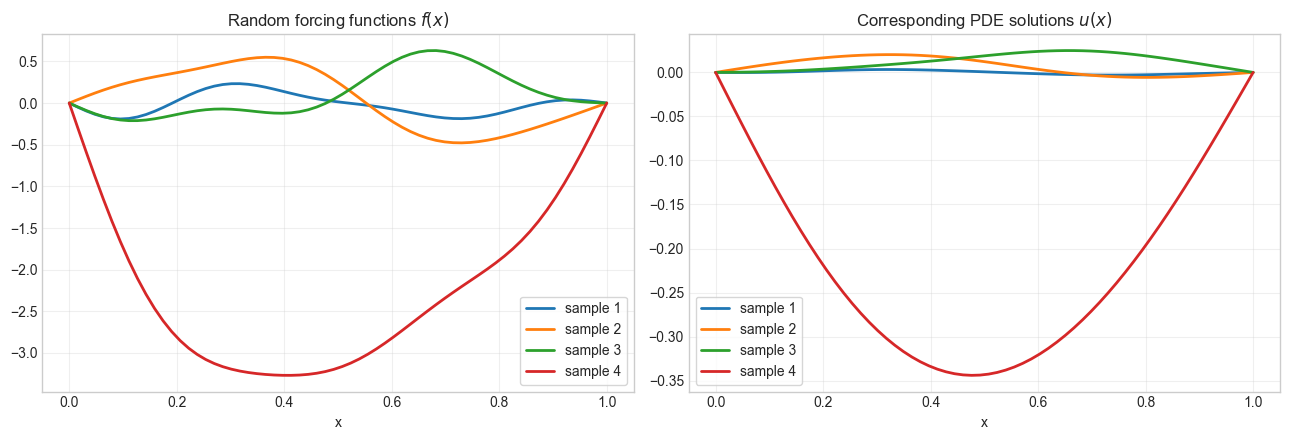

In [3]:
# --- Draw a few examples ----------------------------------------------------
example_coeffs = sample_coefficients(4, rng)
example_forcing, example_solution = build_dataset(example_coeffs, x_sensor)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for i in range(len(example_coeffs)):
    axes[0].plot(x_sensor, example_forcing[i], lw=2, label=f'sample {i + 1}')
    axes[1].plot(x_sensor, example_solution[i], lw=2, label=f'sample {i + 1}')

axes[0].set_title('Random forcing functions $f(x)$')
axes[1].set_title('Corresponding PDE solutions $u(x)$')
for ax in axes:
    ax.set_xlabel('x')
    ax.legend(frameon=True)
plt.tight_layout()


The relationship between these plots is what the model must learn. Notice that the output fields are smoother and lower-amplitude than the forcings. That is a structural property of the PDE operator itself.

Next we generate a training and test set.


In [4]:
# --- Training and test data -------------------------------------------------
n_train = 240
n_test = 60

train_coeffs = sample_coefficients(n_train, rng)
test_coeffs = sample_coefficients(n_test, rng)

f_train, u_train = build_dataset(train_coeffs, x_sensor)
f_test, u_test = build_dataset(test_coeffs, x_sensor)

# Standardize both the input function samples and output solution samples
f_mean = f_train.mean(axis=0, keepdims=True)
f_std = f_train.std(axis=0, keepdims=True) + 1e-6
u_mean = u_train.mean(axis=0, keepdims=True)
u_std = u_train.std(axis=0, keepdims=True) + 1e-6

f_train_n = (f_train - f_mean) / f_std
f_test_n = (f_test - f_mean) / f_std
u_train_n = (u_train - u_mean) / u_std
u_test_n = (u_test - u_mean) / u_std

x_trunk = torch.tensor(x_sensor[:, None], dtype=torch.float32, device=device)

f_train_t = torch.tensor(f_train_n, dtype=torch.float32, device=device)
f_test_t = torch.tensor(f_test_n, dtype=torch.float32, device=device)
u_train_t = torch.tensor(u_train_n, dtype=torch.float32, device=device)
u_test_t = torch.tensor(u_test_n, dtype=torch.float32, device=device)

print('Training forcing tensor:', tuple(f_train_t.shape))
print('Training solution tensor:', tuple(u_train_t.shape))


Training forcing tensor: (240, 64)
Training solution tensor: (240, 64)


## 3. A minimal DeepONet

DeepONet splits the problem into two pieces:

- The **branch net** reads the sampled input function values $f(x_1), \dots, f(x_m)$.
- The **trunk net** reads the coordinate $x$ where we want the solution.

Each network produces a latent representation. Their dot product gives the predicted field value:

$$
\hat{u}(x; f) = \sum_{j=1}^{p} b_j(f)\, t_j(x) + b_0.
$$

This architecture is attractive for PDE operators because it separates

- information about the **input function**, and
- information about the **evaluation location**.

That is what makes evaluation at unseen coordinates natural.


In [14]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, depth):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class DeepONet(nn.Module):
    def __init__(self, n_branch, width=96, latent_dim=80, depth=2):
        super().__init__()
        self.branch = MLP(n_branch, width, latent_dim, depth)
        self.trunk = MLP(1, width, latent_dim, depth)
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, branch_input, coords):
        branch_code = self.branch(branch_input)         # [batch, latent_dim]
        trunk_code = self.trunk(coords)                 # [n_points, latent_dim]
        return branch_code @ trunk_code.T + self.bias   # [batch, n_points]


model = DeepONet(n_branch=n_sensors).to(device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Trainable parameters: {num_params:,}')


DeepONet(
  (branch): MLP(
    (net): Sequential(
      (0): Linear(in_features=64, out_features=96, bias=True)
      (1): Tanh()
      (2): Linear(in_features=96, out_features=96, bias=True)
      (3): Tanh()
      (4): Linear(in_features=96, out_features=80, bias=True)
    )
  )
  (trunk): MLP(
    (net): Sequential(
      (0): Linear(in_features=1, out_features=96, bias=True)
      (1): Tanh()
      (2): Linear(in_features=96, out_features=96, bias=True)
      (3): Tanh()
      (4): Linear(in_features=96, out_features=80, bias=True)
    )
  )
)
Trainable parameters: 40,577


## 4. Training

We minimize mean squared error over full solution fields on the sensor grid:

$$
\mathcal{L}(\theta) = \frac{1}{N}\sum_{i=1}^{N}
\left\|\hat{u}(\cdot; f_i, \theta) - u_i(\cdot)\right\|_2^2.
$$

Because this is an introductory notebook, we keep the setup intentionally small:

- modest dataset size,
- full-batch access to the trunk coordinates,
- plain Adam optimizer,
- no physics-informed loss term.

The purpose here is to understand the operator-learning workflow before moving to more advanced neural operators such as FNOs.


In [15]:
batch_size = 32
epochs = 1000
optimizer = optim.Adam(model.parameters(), lr=2e-3, weight_decay=1e-6)
loss_fn = nn.MSELoss()

train_history = []
test_history = []

for epoch in range(1, epochs + 1):
    model.train()
    perm = torch.randperm(len(f_train_t), device=device)
    batch_losses = []

    for start in range(0, len(f_train_t), batch_size):
        idx = perm[start:start + batch_size]
        pred = model(f_train_t[idx], x_trunk)
        loss = loss_fn(pred, u_train_t[idx])

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        test_pred = model(f_test_t, x_trunk)
        test_loss = loss_fn(test_pred, u_test_t).item()

    train_history.append(np.mean(batch_losses))
    test_history.append(test_loss)

    if epoch == 1 or epoch % 50 == 0:
        print(f'Epoch {epoch:3d} | train MSE = {train_history[-1]:.5f} | test MSE = {test_history[-1]:.5f}')


Epoch   1 | train MSE = 0.37514 | test MSE = 0.16470
Epoch  50 | train MSE = 0.02775 | test MSE = 0.02667
Epoch 100 | train MSE = 0.02863 | test MSE = 0.02744
Epoch 150 | train MSE = 0.02242 | test MSE = 0.02032
Epoch 200 | train MSE = 0.02055 | test MSE = 0.02633
Epoch 250 | train MSE = 0.01551 | test MSE = 0.01444
Epoch 300 | train MSE = 0.01212 | test MSE = 0.01100
Epoch 350 | train MSE = 0.02599 | test MSE = 0.02517
Epoch 400 | train MSE = 0.02381 | test MSE = 0.02354
Epoch 450 | train MSE = 0.02236 | test MSE = 0.02253
Epoch 500 | train MSE = 0.01960 | test MSE = 0.02263
Epoch 550 | train MSE = 0.01513 | test MSE = 0.01352
Epoch 600 | train MSE = 0.01143 | test MSE = 0.01094
Epoch 650 | train MSE = 0.01059 | test MSE = 0.01065
Epoch 700 | train MSE = 0.01059 | test MSE = 0.00865
Epoch 750 | train MSE = 0.00790 | test MSE = 0.00857
Epoch 800 | train MSE = 0.00848 | test MSE = 0.00969
Epoch 850 | train MSE = 0.00672 | test MSE = 0.00751
Epoch 900 | train MSE = 0.00631 | test MSE = 0

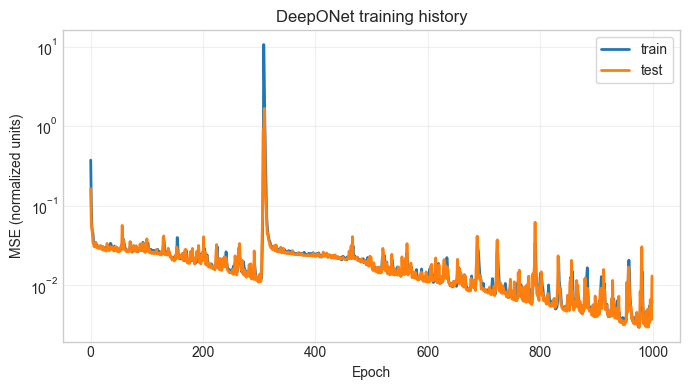

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_history, lw=2, label='train')
ax.plot(test_history, lw=2, label='test')
ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (normalized units)')
ax.set_title('DeepONet training history')
ax.legend(frameon=True)
plt.tight_layout()


## 5. Generalization to unseen forcings

A useful operator learner should solve the PDE for a forcing it has **never seen before**. We first test that standard interpolation setting on the original sensor grid.


Sample RMSE:   5.8792e-03
Sample rel L2: 7.0346e-02


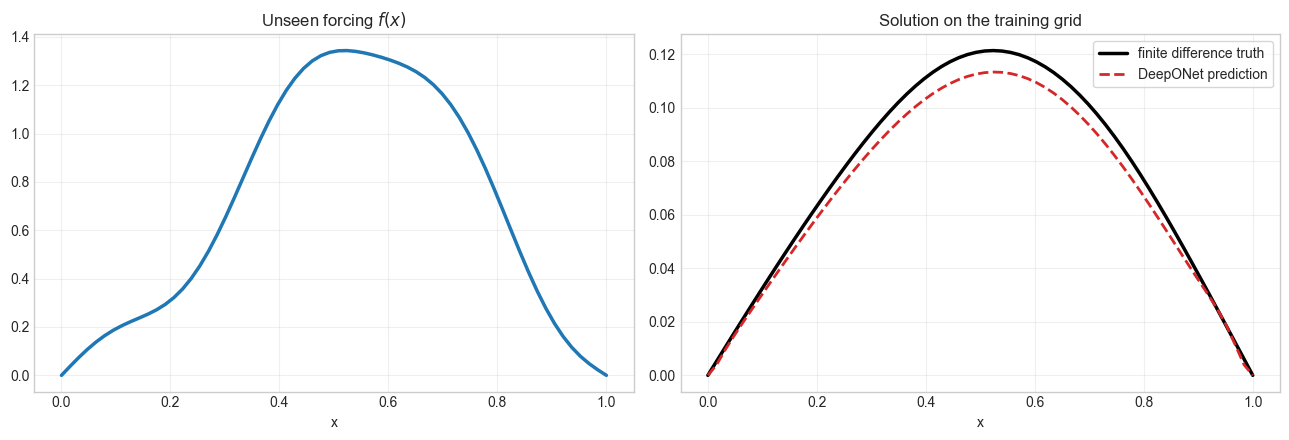

In [17]:
def denormalize_solution(u_norm):
    return u_norm * u_std + u_mean


model.eval()
with torch.no_grad():
    pred_test_n = model(f_test_t, x_trunk).cpu().numpy()

pred_test = denormalize_solution(pred_test_n)

sample_id = 3
f_sample = f_test[sample_id]
u_true = u_test[sample_id]
u_pred = pred_test[sample_id]

rmse = np.sqrt(np.mean((u_pred - u_true) ** 2))
rel_l2 = np.linalg.norm(u_pred - u_true) / np.linalg.norm(u_true)
print(f'Sample RMSE:   {rmse:.4e}')
print(f'Sample rel L2: {rel_l2:.4e}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(x_sensor, f_sample, color='tab:blue', lw=2.5)
axes[0].set_title('Unseen forcing $f(x)$')
axes[0].set_xlabel('x')

axes[1].plot(x_sensor, u_true, color='black', lw=2.5, label='finite difference truth')
axes[1].plot(x_sensor, u_pred, color='tab:red', lw=2.0, ls='--', label='DeepONet prediction')
axes[1].set_title('Solution on the training grid')
axes[1].set_xlabel('x')
axes[1].legend(frameon=True)
plt.tight_layout()


## 6. Why this is operator learning: evaluate on a finer grid

The branch net still sees the same sampled forcing values at the original sensor locations. But the trunk net can now be queried at a *new set of coordinates*.

That means we can evaluate the learned operator on a finer grid without retraining the model. This is one of the clearest conceptual differences between operator learning and a conventional vector-to-vector regressor tied to one fixed discretization.

Below we compare the model against a finite-difference solution on a much finer grid for the same unseen forcing.


Fine-grid RMSE:   5.9147e-03
Fine-grid rel L2: 7.0368e-02


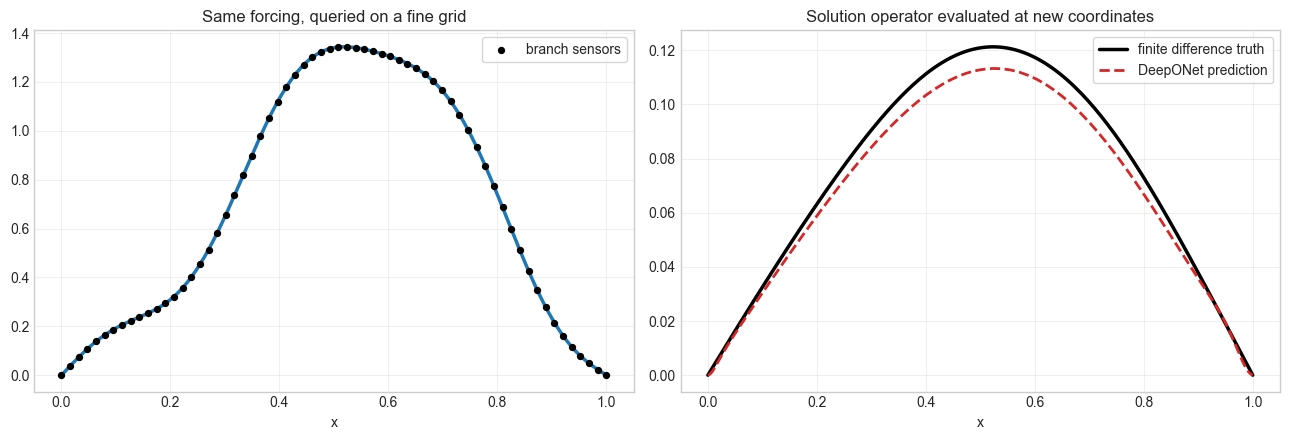

In [18]:
# Reconstruct the continuous forcing from the test coefficients for one sample
fine_points = 256
x_fine = np.linspace(0.0, 1.0, fine_points)
coeff_sample = test_coeffs[sample_id]

f_fine = forcing_from_coeffs(x_fine, coeff_sample)
u_fine_true = solve_poisson_fd(f_fine, x_fine)

x_fine_t = torch.tensor(x_fine[:, None], dtype=torch.float32, device=device)
branch_sample_t = torch.tensor(f_test_n[sample_id:sample_id + 1], dtype=torch.float32, device=device)

with torch.no_grad():
    u_fine_pred_n = model(branch_sample_t, x_fine_t).cpu().numpy()[0]

# Interpolate output normalization statistics from the training grid to the fine grid.
# This is a practical shortcut for the notebook; for larger problems one often normalizes
# with scalar statistics or learns directly in physical units.
u_mean_fine = np.interp(x_fine, x_sensor, u_mean.ravel())
u_std_fine = np.interp(x_fine, x_sensor, u_std.ravel())
u_fine_pred = u_fine_pred_n * u_std_fine + u_mean_fine

fine_rmse = np.sqrt(np.mean((u_fine_pred - u_fine_true) ** 2))
fine_rel_l2 = np.linalg.norm(u_fine_pred - u_fine_true) / np.linalg.norm(u_fine_true)
print(f'Fine-grid RMSE:   {fine_rmse:.4e}')
print(f'Fine-grid rel L2: {fine_rel_l2:.4e}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(x_fine, f_fine, color='tab:blue', lw=2.5)
axes[0].scatter(x_sensor, forcing_from_coeffs(x_sensor, coeff_sample), s=18, color='black', zorder=3, label='branch sensors')
axes[0].set_title('Same forcing, queried on a fine grid')
axes[0].set_xlabel('x')
axes[0].legend(frameon=True)

axes[1].plot(x_fine, u_fine_true, color='black', lw=2.5, label='finite difference truth')
axes[1].plot(x_fine, u_fine_pred, color='tab:red', lw=2.0, ls='--', label='DeepONet prediction')
axes[1].set_title('Solution operator evaluated at new coordinates')
axes[1].set_xlabel('x')
axes[1].legend(frameon=True)
plt.tight_layout()


## 7. Takeaways

This example is intentionally small, but it captures the essential operator-learning workflow for PDEs.

Key ideas:

- A PDE induces a map between functions, not just between finite-dimensional vectors.
- DeepONet separates the **input function representation** (branch net) from the **query coordinate representation** (trunk net).
- Once trained, the model can predict solutions for **new forcings**.
- Because the output is parameterized by coordinates, the same model can often be queried on **new grids**.

Important caveats:

- This Poisson problem is linear and one-dimensional. Real Earth-science PDEs are often nonlinear, time-dependent, and much stiffer.
- The fine-grid test here works because the underlying forcing is smooth and the operator is simple. Resolution transfer becomes harder for turbulent or multiscale systems.
- For structured spatial grids, **Fourier Neural Operators (FNOs)** and related architectures are often more scalable than a basic DeepONet.

Possible extensions for class discussion or assignments:

1. Replace the Poisson equation with an advection-diffusion problem.
2. Learn an operator that maps an initial condition to a later-time PDE state.
3. Compare DeepONet against a standard multilayer perceptron tied to one fixed grid.
4. Add noise to the forcing sensors and study robustness.
5. Move from linear Poisson to a nonlinear elliptic problem or a parabolic PDE.
